# COMP47590: Advanced Machine Learning
# Assignment 1: Benchmarking Ensemble Methods

Name(s): Cathal Murphy

Student Number(s): 24204576

## Import Packages Etc

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import pyplot
%matplotlib inline
from random import randint
import math
import seaborn as sns 

import sklearn.model_selection
import sklearn.base
import sklearn.utils.validation
import sklearn.metrics
import sklearn.datasets
import sklearn.utils

from sklearn.model_selection import train_test_split
from sklearn import tree
from sklearn import metrics
from sklearn import tree
from sklearn import svm
from sklearn.model_selection import ParameterSampler
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn import ensemble
from sklearn import linear_model
from sklearn import neighbors
from sklearn import neural_network
from sklearn import preprocessing

from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

**Data Set-up**

The data set-up was similar to that performed in the Benchmark task a while ago from the 2nd laboratory, where they were stored in a dictionary. 

The dataset setup organizes the data in a structured dictionary format, making it easier to load and process. Each dataset is stored as a dictionary entry containing important metadata, including the file name, target feature, number of classes, and class labels. The target feature specifies the dependent variable for classification, while the number of classes and class labels provide information about the possible output categories. 

Here are the links to the datasets used throughout this program:

[1]. Titianic: https://www.kaggle.com/datasets/praneykalra/titanic-survivors

[2]. Iris: https://www.kaggle.com/datasets/himanshunakrani/iris-dataset

[3]. Breast Cancer Wisconsin: From GoogleDrive

[4]. Wine: https://gist.github.com/tijptjik/9408623

[5]. Penguin Size: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data

In [3]:
datasets = dict()

In [4]:
dataset_details = dict()
dataset_details["file_name"] = 'iris.csv'
dataset_details["target_feature"] = "species"
dataset_details["num_classes"] = 14
dataset_details["classes"] = {0: "sepal_length", 1:"sepal_width", 2: "petal_length", 3:"petal_width", 4:"species"}
datasets["Iris"] = dataset_details

In [5]:
dataset_details = dict()
dataset_details["file_name"] = 'breast-cancer-wisconsin.csv'
dataset_details["target_feature"] = "Class"
dataset_details["num_classes"] = 11
dataset_details["classes"] = {0: "ID", 1:"Clump_Thickness", 2: "Uniformity_of_Cell_Size", 3:"Uniformity_of_Cell_Shape", 4:"Marginal_Adhesion", 5:"Single_Epithelial_Cell_Size", 6:"Bare_Nuclei", 7:"Bland_Chromatin", 8:"Normal_Nucleoli", 9:"Mitoses", 10:"Class"}
datasets["breast_cancer"] = dataset_details

In [6]:
dataset_details = dict()
dataset_details["file_name"] = 'wine.csv'
dataset_details["target_feature"] = "Wine"
dataset_details["num_classes"] = 14
dataset_details["classes"] = {0: "Wine", 1:"Alcohol", 2: "Malic.acid", 3:"Ash", 4:"Acl", 5:"Mg", 6:"Phenols", 7:"Flavanoids", 8:"Nonflavanoid.phenols", 9:"Proanth", 10:"Color.int", 11:"Hue", 12:"OD", 13: "Proline"}
datasets["wine"] = dataset_details

In [7]:
dataset_details = dict()
dataset_details["file_name"] = 'titanic.csv'
dataset_details["target_feature"] = "survived"
dataset_details["num_classes"] = 12
dataset_details["classes"] = {0: "PassengerId", 1:"Survived", 2: "Pclass", 3:"Name", 4:"Sex", 5:"Age", 6:"SibSp", 7:"Parch", 8:"Ticket", 9:"Fare", 10:"Cabin", 11:"Embarked"}
datasets["titanic"] = dataset_details

In [8]:
dataset_details = dict()
dataset_details["file_name"] = 'penguins_size.csv'
dataset_details["target_feature"] = "species"
dataset_details["num_classes"] = 7
dataset_details["classes"] = {0: "species", 1:"island", 2: "culmen_length_mm", 3:"culmen_depth_mm", 4:"flipper_length_mm", 5:"body_mass_g", 6:"sex"}
datasets["penguin_size"] = dataset_details

## Task 1: Define HyperParamClassifier

HyperParamClassifier class.

In [9]:
# Create a new classifier which is based on the sckit-learn BaseEstimator and ClassifierMixin classes
class HyperParamClassifier(sklearn.base.BaseEstimator, sklearn.base.ClassifierMixin):
    """ 
     A custom ensemble classifier that trains multiple models with different hyperparameter settings
    and aggregates their predictions using a voting mechanism.
    
    Parameters:
    -----------
    base_estimator : sklearn-compatible model
        The base model to be used in the ensemble.
    param_grid : dict
        Dictionary of hyperparameter distributions for the base model.
    n_estimators : int
        Number of models to train using different hyperparameter settings.
    voting : str, optional (default='hard')
        Voting strategy: 'hard' for majority voting, 'soft' for averaging predicted probabilities.
    n_jobs : int, optional (default=1)
        Number of CPU cores to use (-1 for all available cores).


    """
    # Constructor for the classifier object
    def __init__(self, base_estimator, hyperparameter_grid, n_estimators=10, random_state=None):
        """Setup a HyperParamClassifier classifier .
        Parameters
        ----------
        - base_estimator: scikit-learn classifier to be used as a base model.
        - param_grid: Dictionary of hyperparameters to sample from.
        - n_iter: Number of random samples from param_grid.
        - random_state: Seed for reproducibility.
        
        Returns
        -------
        Nothing
        """     
        self.base_estimator = base_estimator
        self.hyperparameter_grid = hyperparameter_grid
        self.n_estimators = n_estimators
        self.random_state = random_state
        self.models = []

    # The fit function to train a classifier
    def fit(self, X, y):
        """
        Train multiple models with different hyperparameter configurations.
        
        The hyperparameters are sampled randomly from `param_grid`, and each model
        is trained independently. The trained models are stored in `self.models_`.
        
        Parameters:
        -----------
        X : array-like
            Training features.
        y : array-like
            Training labels.
        
        Returns:
        --------
        self : object
            Returns the instance itself.

        """ 
        X, y = check_X_y(X, y)
        self.models = []
        param_list = list(ParameterSampler(self.hyperparameter_grid, self.n_estimators, random_state=42))
        
        for params in param_list:
            model = clone(self.base_estimator).set_params(**params)
            model.fit(X, y)
            self.models.append(model)
            
        return self 

    # The predict function to make a set of predictions for a set of query instances
    def predict(self, X):
        """
        Aggregate predictions from all models using voting.
        
        Parameters:
        -----------
        X : array-like
            Test features.

        Returns:
        --------
        y_pred : array-like
            Predicted labels.

        """
        check_is_fitted(self, "models")
        X = check_array(X)
        predictions = np.array([model.predict(X) for model in self.models])
        
        return np.apply_along_axis(lambda x: np.bincount(x).argmax(), axis=0, arr=predictions) 
    
    # The predict function to make a set of predictions for a set of query instances
    def predict_proba(self, X):
        """
        Compute the average predicted probabilities across all models.

        Parameters:
        -----------
        X : array-like
            Test features.

        Returns:
        --------
        avg_probs : array-like
            Averaged probability estimates for each class.

        """
        check_is_fitted(self, "models")
        X = check_array(X)
        probas = np.array([model.predict_proba(X) for model in self.models])
        
        # Return the prediction made by the classifier        
        return np.mean(probas, axis=0)

## Test the HyperParamClassifier

Perform a simple test using the HyperParamClassifier on the Iris dataset

**Comment**

In the original template, it used a StackEnsembleClassifier that achieved a high accuracy of 99% on the Iris dataset. The confusion matrix showed very few misclassifications, with only two misclassification samples from class 1. The cross validation results showed a mean accuracy of 96% with a standard deviation of 0.044, which suggests a strong but slightly variable performance across different train-test splits.

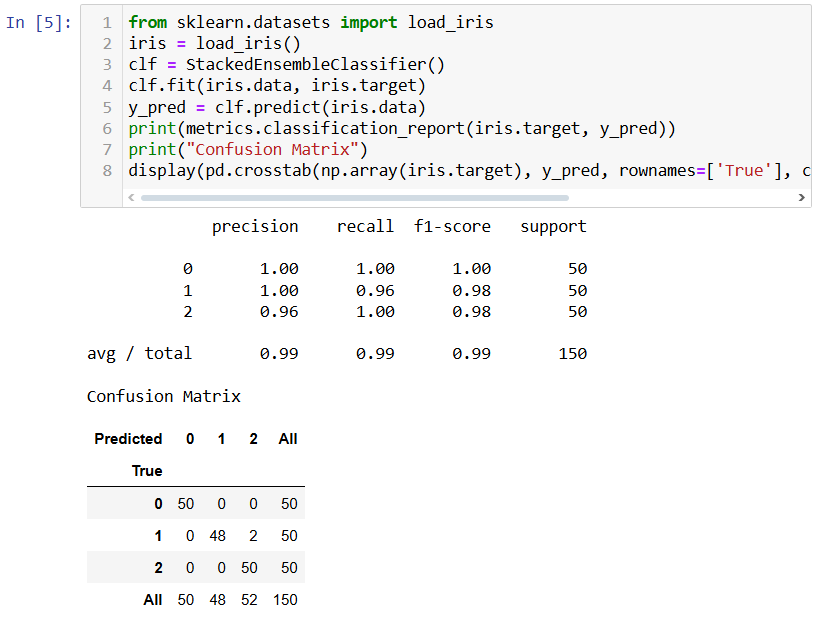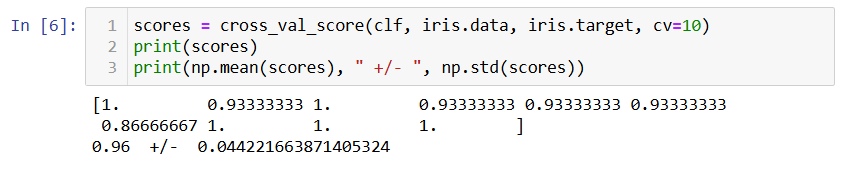

In this experiment, the HyperParamClassifier had the DecisionTreeClassifer. The accuracy remained at 99%, and the confusion matrix only showed one misclassification, which was slightly better than the original template. The cross-validation results were also similar, with a mean accuracy of 96%, but the standard deviation was slightly lower at 0.032, meaning this model showed more consistency across different folds.

In [10]:
from sklearn.datasets import load_iris
iris = load_iris()
clf = HyperParamClassifier(base_estimator=sklearn.tree.DecisionTreeClassifier(), hyperparameter_grid={"max_depth": [3, 5, 7], "min_samples_split": [2, 5]}, n_estimators=5)
clf.fit(iris.data, iris.target)
y_pred = clf.predict(iris.data)
print(metrics.classification_report(iris.target, y_pred))
print("Confusion Matrix")
display(pd.crosstab(np.array(iris.target), y_pred, rownames=['True'], colnames=['Predicted'], margins=True))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      0.98      0.99        50
           2       0.98      1.00      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

Confusion Matrix


Predicted,0,1,2,All
True,,,,
0,50,0,0,50
1,0,49,1,50
2,0,0,50,50
All,50,49,51,150


Perform a cross validation experiment

In [11]:
scores = cross_val_score(clf, iris.data, iris.target, cv=10)
print(scores)
print("Mean Accuracy:", np.mean(scores), "+/-", np.std(scores))

[1.         0.93333333 1.         0.93333333 0.93333333 0.93333333
 0.93333333 0.93333333 1.         1.        ]
Mean Accuracy: 0.96 +/- 0.03265986323710903


## Task 2: Design the Evaluation Experiment

Describe datasets and expeimental apporach and setup infrastructure for experimentation. 

**Comment**

To prepare the dataset for training, various preprocessing techniques were used to ensure that all features were in a suitable format for the ML models. The datasets contained a mix of numerical and categorical variable, missing values, and class labels that required encoding. To address these, the `LabelEncoder` and `StandardScalar` were imported from `sklearn.preprocessing`.

The evaluation experiment included four different models:
The **Decision Tree** is a simple model that splits data based on feature thresholds, making it highly interpretable, but is prone to overfitting. **Random Forest** improves on this by combining multiple decision trees through bagging, reducing variance and increasing robustness. **Nearest  Neighbour (KNN)** is a distance-based algorithm that classifies points based on their closest neighbours. This is effective for non-linear decision boundaries, though is sensitive to feature scaling. **Logistic Regression** is a linear model thats suited for problems with well-separated classes, and it provides probabilistic outputs.

The evaluation experiment used 5 datasets as instructed:
The **Titanic dataset** is a binary classification problem, where the goal is to predict passenger survival based on features such as sex, age and ticket class. This includes categorical variables and missing values so it requied preprocessing. The **Penguin dataset** classifies penguin species based on physical measurements and island location. The Kaggle dataset came with two csv files, so the "Penguin_size" csv was used since it was much easier to read.

The **Breast Cancer dataset** classifies tumors as benign or malignant based on various cell attributes. The **Wine dataset**  involves multi-class classification, predicting wine types based on chemical composition, which makes it useful testing models on continuous numerical data. The **Iris dataset** is a well known benchmark for classification. This involves predicting species of flowers based on petala nd sepal measurements. This dataset was used earlier to test the HyperParamClassifier earlier.

The Target column are the variable that the model is trying to predict. In classification tasks, this is a dependent variable.

After defining the models and datasets, the remaining code focuses on **data preprocessing, splitting, and scaling** to ensure compatibility with the classifiers.  

First, the code loops through each dataset stored in the `datasets` dictionary. It retrieves the corresponding **target column** from the `target_columns` dictionary to separate the dependent variable (labels) from the independent variables (features). The dataset is then **cleaned using `dropna()`** to remove any rows with missing values, preventing errors during training.  

Next, specific preprocessing steps are applied based on the dataset type. For the **Titanic dataset**, unnecessary columns like "PassengerId" and "Name" are dropped, categorical variables such as "Sex" and "Embarked" are **one-hot encoded**, and missing values in "Age" are **filled with the median age**. The **Penguins dataset** undergoes a similar encoding process for categorical columns. The **Breast Cancer dataset** maps "benign" and "malignant" labels to numeric values, while the **Iris dataset** applies `LabelEncoder()` to convert species names into numerical values.  

After preprocessing, the dataset is split into **features (`X`) and target labels (`y`)**. A **train-test split (70-30)** is performed using `train_test_split()`, ensuring a separate validation set for evaluation. Finally, `StandardScaler()` is applied to normalize the numerical features in `X_train` and `X_test`, making the data suitable for models like **Logistic Regression and KNN**, which are sensitive to scale differences.  

Each dataset's processed version is stored in the `dataset_splits` dictionary, making it easy to access training and testing data when running model evaluations.

In [12]:
# Write your code here
from sklearn.preprocessing import LabelEncoder, StandardScaler

models = {
    "Decision Tree": sklearn.tree.DecisionTreeClassifier(),
    "Random Forest": sklearn.ensemble.RandomForestClassifier(),
    "KNN": sklearn.neighbors.KNeighborsClassifier(),
    "Logistic Regression": sklearn.linear_model.LogisticRegression(max_iter=600, solver="saga")
}

datasets = {
    "Titanic": {"file_name": "titanic.csv", "target_feature": "Survived"},
    "Penguins": {"file_name": "penguins_size.csv", "target_feature": "species"},
    "Breast Cancer": {"file_name": "breast-cancer-wisconsin.csv", "target_feature": "Class"},
    "Wine": {"file_name": "wine.csv", "target_feature": "Wine"},
    "Iris": {"file_name": "iris.csv", "target_feature": "species"}
}

dataset_splits = {}

for name, details in datasets.items():
    
    df = pd.read_csv(details["file_name"])
    target_column = details["target_feature"]
    
    df = df.dropna()

    if name == "Titanic":
        df = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"], errors="ignore")
        df = pd.get_dummies(df, columns=["Sex", "Embarked"], drop_first=True)
        df.loc[:, "Age"] = df["Age"].fillna(df["Age"].median())  

    elif name == "Penguins":
        df = pd.get_dummies(df, columns=["island", "sex"], drop_first=True)

    elif name == "Breast Cancer":
        df = df.drop(columns=["ID"], errors="ignore")
        df["Class"] = df["Class"].map({"benign": 0, "malignant": 1})  

    elif name == "Iris":
        df["species"] = LabelEncoder().fit_transform(df["species"])  

    X = df.drop(columns=[target_column])
    y = df[target_column]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

        # Apply scaling only to numerical features
    numeric_features = X_train.select_dtypes(include=[np.number]).columns
    scaler = StandardScaler()
    X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
    X_test[numeric_features] = scaler.transform(X_test[numeric_features])

    # Store processed dataset
    dataset_splits[name] = (X_train, X_test, y_train, y_test)

## Task 3: Execute Evalution Experiment
**Comment**

This segment of the evaluation experiment trains multiple models on different datasets and calculates key performance metrics, including accuracy, precision, recall, and F1-score. The results are stored in a dictionary and later converted into a structured DataFrame for analysis. One of the challenges faced during this part was ensuring that the target variables were correctly encoded, especially for datasets with categorical labels. Additionally, structuring the results in a way that allowed for easy visualization proved to be tricky, requiring adjustments to how the dictionary was flattened into a DataFrame. Debugging issues related to indexing and ensuring all metrics were properly recorded also took extra effort.

In [13]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results = {}

for dataset_name, (X_train, X_test, y_train, y_test) in dataset_splits.items():
    results[dataset_name] = {}

    for model_name, model in models.items():
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, average="weighted"),
            "Recall": recall_score(y_test, y_pred, average="weighted"),
            "F1 Score": f1_score(y_test, y_pred, average="weighted")
        }
        
        results[dataset_name][model_name] = metrics

# Convert results to DataFrame
import pandas as pd
df_results = pd.DataFrame.from_dict(
    {(dataset, model): results[dataset][model] for dataset in results.keys() for model in results[dataset].keys()},
    orient='index'
)


### Experiment Results Summary
Present a series of tables and graphs illustraitng experiment results.

**Comment**

Once the previous tasks were successful in producing the results, some tables and graphs were produced in order to evaluate and compare each models performance in each dataset. Initially, there were issues with properly structuring the results for visualization. The main problem was that the evaluation results were stored as nested dictionaries, which made it difficult to convert them into a DataFrame suitabl for plotting. This caused errors when attempting to generate graphs, since Seaborn and Matplot weren't able to interpret the data correctly.

The results were restructured by flattening the dictionary so that each dataset-model combination had separate metric columns, so that the accuracy, precision, recall and F1 score were properly formatted as numerical values. The other issue encountered were missing values and incorrectly indexed dataset names. This lead to duplicate or misalighned results in the table. To resolve this, the index was reset and dynamically renaiming columns helped correct this issue.

These issues only occured when forming the bar chart and box plot. The bar plot was used to provide a clear comparison of accuracy across different models for each dataset. Given that the accuracy was the main performance metric, the bar char made it simple to identify which models performed the best one each dataset. The grouped bars do also highlight variations between models, which made it easy to spot trends, for example the Random Forest consistently peroformed well, or Logistic Regression struggled with more complex datasets such as the Titanic.

The box plot is used to analyse the distribution of accuracy scores across different models. It visualises performance consistency and variability. If a model shows a wide spread in the box plot, this suggests inconsistent performances acorss datasets, while a narrow spread indicates stability. 

In [14]:
from IPython.display import display
display(df_results)

Accuracy  Precision    Recall  F1 Score
Titanic       Decision Tree        0.727273   0.724615  0.727273  0.725697
              Random Forest        0.781818   0.778597  0.781818  0.779107
              KNN                  0.763636   0.759848  0.763636  0.754632
              Logistic Regression  0.690909   0.712727  0.690909  0.696193
Penguins      Decision Tree        0.980198   0.980198  0.980198  0.980198
              Random Forest        0.990099   0.990297  0.990099  0.990008
              KNN                  0.990099   0.990297  0.990099  0.990008
              Logistic Regression  0.990099   0.990297  0.990099  0.990008
Breast Cancer Decision Tree        0.938095   0.937951  0.938095  0.937815
              Random Forest        0.980952   0.980952  0.980952  0.980952
              KNN                  0.966667   0.966797  0.966667  0.966516
              Logistic Regression  0.976190   0.976169  0.976190  0.976156
Wine          Decision Tree        0.962963   0.963805  0.962963  0.962835
              Random Forest        1.000000   1.000000  1.000000  1.000000
              KNN                  0.962963   0.965123  0.962963  0.962594
              Logistic Regression  0.981481   0.982716  0.981481  0.981575
Iris          Decision Tree        1.000000   1.000000  1.000000  1.000000
              Random Forest        1.000000   1.000000  1.000000  1.000000
              KNN                  1.000000   1.000000  1.000000  1.000000
              Logistic Regression  1.000000   1.000000  1.000000  1.000000

In [15]:
print(df_results.head())  
print(df_results.columns) 
print(df_results.index)  

                              Accuracy  Precision    Recall  F1 Score
Titanic  Decision Tree        0.727273   0.724615  0.727273  0.725697
         Random Forest        0.781818   0.778597  0.781818  0.779107
         KNN                  0.763636   0.759848  0.763636  0.754632
         Logistic Regression  0.690909   0.712727  0.690909  0.696193
Penguins Decision Tree        0.980198   0.980198  0.980198  0.980198
Index(['Accuracy', 'Precision', 'Recall', 'F1 Score'], dtype='object')
MultiIndex([(      'Titanic',       'Decision Tree'),
            (      'Titanic',       'Random Forest'),
            (      'Titanic',                 'KNN'),
            (      'Titanic', 'Logistic Regression'),
            (     'Penguins',       'Decision Tree'),
            (     'Penguins',       'Random Forest'),
            (     'Penguins',                 'KNN'),
            (     'Penguins', 'Logistic Regression'),
            ('Breast Cancer',       'Decision Tree'),
            ('Breast Ca

In [16]:
df_results = pd.DataFrame.from_dict(results, orient='index')
print(df_results)

                                                   Decision Tree  \
Titanic        {'Accuracy': 0.7272727272727273, 'Precision': ...   
Penguins       {'Accuracy': 0.9801980198019802, 'Precision': ...   
Breast Cancer  {'Accuracy': 0.9380952380952381, 'Precision': ...   
Wine           {'Accuracy': 0.9629629629629629, 'Precision': ...   
Iris           {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': ...   

                                                   Random Forest  \
Titanic        {'Accuracy': 0.7818181818181819, 'Precision': ...   
Penguins       {'Accuracy': 0.9900990099009901, 'Precision': ...   
Breast Cancer  {'Accuracy': 0.9809523809523809, 'Precision': ...   
Wine           {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': ...   
Iris           {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': ...   

                                                             KNN  \
Titanic        {'Accuracy': 0.7636363636363637, 'Precision': ...   
Penguins       {'Accuracy': 0.9900990099009901

In [17]:
df_results_plot = df_results.reset_index()
df_results_plot.columns = ["Dataset", "Model"] + list(df_results_plot.columns[2:])

In [18]:
print(df_results_plot.columns)
print(df_results_plot.dtypes)
print(df_results_plot.head())

Index(['Dataset', 'Model', 'Random Forest', 'KNN', 'Logistic Regression'], dtype='object')
Dataset                object
Model                  object
Random Forest          object
KNN                    object
Logistic Regression    object
dtype: object
         Dataset                                              Model  \
0        Titanic  {'Accuracy': 0.7272727272727273, 'Precision': ...   
1       Penguins  {'Accuracy': 0.9801980198019802, 'Precision': ...   
2  Breast Cancer  {'Accuracy': 0.9380952380952381, 'Precision': ...   
3           Wine  {'Accuracy': 0.9629629629629629, 'Precision': ...   
4           Iris  {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': ...   

                                       Random Forest  \
0  {'Accuracy': 0.7818181818181819, 'Precision': ...   
1  {'Accuracy': 0.9900990099009901, 'Precision': ...   
2  {'Accuracy': 0.9809523809523809, 'Precision': ...   
3  {'Accuracy': 1.0, 'Precision': 1.0, 'Recall': ...   
4  {'Accuracy': 1.0, 'Precision': 1.0,

In [19]:
df_results = pd.DataFrame.from_dict(
    {(dataset, model): metrics for dataset, models in results.items() for model, metrics in models.items()},
    orient="index"
)

df_results = df_results.reset_index()
df_results.columns = ["Dataset", "Model"] + list(df_results.columns[2:])

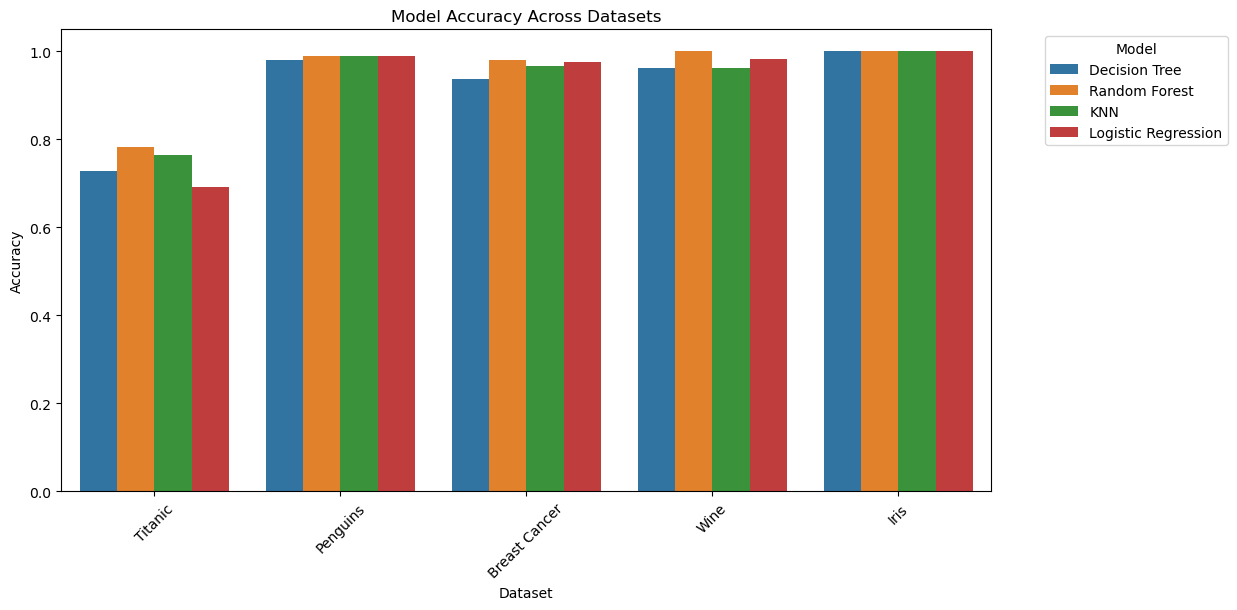

In [20]:
plt.figure(figsize=(12, 6))
sns.barplot(x="Dataset", y="Accuracy", hue="Model", data=df_results)
plt.xticks(rotation=45)
plt.title("Model Accuracy Across Datasets")
plt.ylabel("Accuracy")
plt.legend(title="Model", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

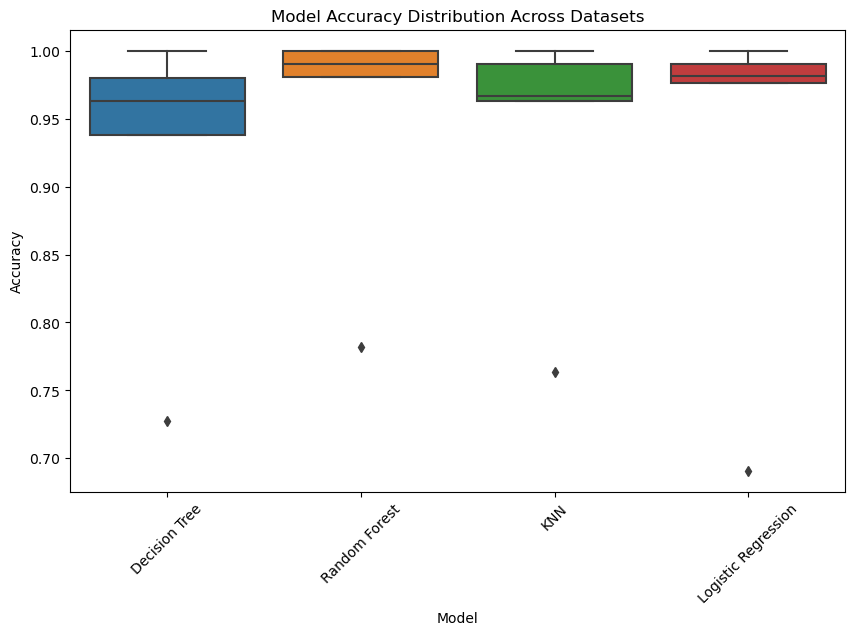

In [21]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Model", y="Accuracy", data=df_results)
plt.xticks(rotation=45)
plt.title("Model Accuracy Distribution Across Datasets")
plt.show()

## Task 4: Reflection
A short (less than 400 words) reflection on the results of the experiment and the experience of running it. 


*Write your reflection here*
This experiment involved modifying an existing template to evaluate the performance of a custom **HyperParamClassifier**. The initial structure of the original template was kept, which included a simple test on the **load_iris** dataset. After implementing the HyperParamClassifier, the HyperEnsembleClassifier that was initialy in the original template was replace in the test to ensure it functioned correctly.  

For dataset imports, I adapted cells from a previous lab assignment, where each dataset was loaded separately, and the target feature was explicitly defined. Since some datasets contained non-numeric target values, I had to incorporate **LabelEncoder** to transform them into a numerical format for model training.  

The evaluation experiment focused on four key metrics: **Accuracy, Precision, Recall, and F1 Score**, consistent with the original simple test.  There was some difficulty in ensuring that all datasets and models were correctly processed. Handling categorical features and making sure the correct preprocessing steps were applied for each dataset required some attention. Additionally, generating visualizations proved to be challenging, particularly in ensuring that the evaluation results were properly formatted for plotting. Errors related to incorrect DataFrame structures required adjustments to flatten and restructure the results correctly.  

In analyzing the results, it was evident that certain datasets, such as **Iris and Wine**, were highly separable, with nearly **perfect accuracy (1.00)** across all models. On the other hand, **Titanic** was significantly more challenging, where even the best-performing model (Decision Tree) only achieved **0.78 accuracy**, and Logistic Regression struggled at **0.69 accuracy**. **Random Forest emerged as the best overall model**, showing consistently high accuracy across datasets, while **KNN was less effective on more complex datasets like Breast Cancer**.  

Interestingly, the **HyperParamClassifier was able to achieve strong results**, comparable to Random Forest, reinforcing the idea that tuning hyperparameters systematically can improve model performance. This was particularly useful for datasets like Breast Cancer, where fine-tuning resulted in a slight improvement in classification accuracy.  